<h1>Extracting and Visualizing Stock Data</h1>

**Note:** *If you're viewing this notebook on GitHub, please note that interactive elements such as Plotly charts may not display correctly. For the fully interactive version, please see the Binder launch link in the README of this repository. If you're viewing it on Binder, please **re-run the cells to activate full interactivity**. Static PNG previews are shown by default.*

<h2>Description</h2>


Extracting essential data from a dataset and displaying it is a necessary part of data science; therefore individuals can make correct decisions based on the data. In this data extraction project, we will extract some stock data, and then display this data in a graph.


<h2>Table of Contents</h2>
<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ul>
        <li>Defining an Auxiliary Function that Makes a Graph</li>
        <li>Using yfinance to Extract Tesla Stock Data</li>
        <li>Using Webscraping to Extract Tesla Revenue Data</li>
        <li>Using yfinance to Extract GameStop Stock Data</li>
        <li>Using Webscraping to Extract GME Revenue Data</li>
        <li>Plotting Tesla Stock Graph</li>
        <li>Plotting GameStop Stock Graph</li>
        <li>Saving the Extracted Data</li>
    </ul>
</div>
<hr>


In [1]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import kaleido
from IPython.display import Image, display
pio.renderers.default = "iframe"

## Defining a Graphing Function


In [2]:
def make_graph(stock_data, revenue_data, stock, show=True):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, subplot_titles=("Historical Share Price", "Historical Revenue"), vertical_spacing = .3)
    stock_data_specific = stock_data[(stock_data.Date >= '2011-08-01')&(stock_data.Date <= '2025-06-30')]
    revenue_data_specific = revenue_data[(revenue_data.Date >= '2011-08-01')&(revenue_data.Date <= '2025-06-30')]
    fig.add_trace(go.Scatter(x=pd.to_datetime(stock_data_specific.Date), y=stock_data_specific.Close.astype("float"), name="Share Price"), row=1, col=1)
    fig.add_trace(go.Scatter(x=pd.to_datetime(revenue_data_specific.Date), y=revenue_data_specific.Revenue.astype("float"), name="Revenue"), row=2, col=1)
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($US)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($US Millions)", row=2, col=1)
    fig.update_layout(showlegend=False,
    height=900,
    title=stock.info['longName'],
    xaxis_rangeslider_visible=True)
    if show:
        fig.show()
    return fig

## Using yfinance to Extract Tesla Stock Data


Using the `Ticker` function enter the Tesla ticker symbol to create a ticker object.


In [3]:
tesla=yf.Ticker('TSLA')

Using the ticker object and the function `history` we will extract stock information and save it in a dataframe named `tesla_data`. The `period` parameter is set to ` "max" ` so we get information for the maximum amount of time.


In [4]:
tesla_data=tesla.history(period='max')

In [5]:
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## Using Webscraping to Extract Tesla Revenue Data


We will use the `requests` library to download the webpage https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue.


In [6]:
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36"
}

html_data = requests.get(url, headers=headers).text

Now we will parse the html data using `beautiful_soup`.


In [7]:
soup=BeautifulSoup(html_data,'html.parser')

In [8]:
print(soup.prettify()[:3000])

<!DOCTYPE html>
<!--[if lt IE 7]>      <html class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!-->
<html class="no-js">
 <!--<![endif]-->
 <head>
  <meta charset="utf-8"/>
  <meta content="IE=edge,chrome=1" http-equiv="X-UA-Compatible"/>
  <link href="https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue" rel="canonical"/>
  <title>
   Tesla Revenue 2011-2025 | TSLA | MacroTrends
  </title>
  <link href="/assets/images/icons/FAVICON/macrotrends-favicon-96.png" rel="icon" type="image/x-icon"/>
  <meta content="Tesla annual/quarterly revenue history and growth rate from 2011 to 2025. Revenue can be defined as the amount of money a company receives from its customers in exchange for the sales of goods or services.  Revenue is the top line item on an income statement from which all costs and expenses are subtracted to arrive at net 

We will extract the table with `Tesla Revenue` and store it into a dataframe named `tesla_revenue`.

In [9]:
tesla_revenue=pd.DataFrame(columns=['Date','Revenue'])

for row in soup.find_all('tbody')[1].find_all('tr'):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    tesla_revenue=pd.concat([tesla_revenue,pd.DataFrame({'Date':[date],'Revenue':[revenue]})],ignore_index=True)

The following line will remove the comma and dollar sign from the `Revenue` column. 

In [10]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)

The following lines will remove an null or empty strings in the Revenue column.


In [11]:
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

In [12]:
tesla_revenue.tail()

,Date,Revenue
54,2011-12-31,39
55,2011-09-30,58
56,2011-06-30,58
57,2011-03-31,49
58,2010-12-31,36


## Using yfinance to Extract GameStop Stock Data


Using the `Ticker` function enter the GameStop ticker symbol to create a ticker object.


In [13]:
gamestop=yf.Ticker('GME')

Using the ticker object and the function `history`, we will extract stock information and save it in a dataframe named `gme_data`.

In [14]:
gme_data=gamestop.history(period='max')

In [15]:
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578048,1.607505,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Using Webscraping to Extract GME Revenue Data


We will use the `requests` library to download the webpage https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue.


In [16]:
html_data_2=requests.get('https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue',headers=headers).text

Now we will parse the html data using `beautiful_soup`.


In [17]:
soup_2=BeautifulSoup(html_data_2,'html.parser')
print(soup_2.prettify()[:3000])

<!DOCTYPE html>
<!--[if lt IE 7]>      <html class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!-->
<html class="no-js">
 <!--<![endif]-->
 <head>
  <meta charset="utf-8"/>
  <meta content="IE=edge,chrome=1" http-equiv="X-UA-Compatible"/>
  <link href="https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue" rel="canonical"/>
  <title>
   GameStop Revenue 2012-2025 | GME | MacroTrends
  </title>
  <link href="/assets/images/icons/FAVICON/macrotrends-favicon-96.png" rel="icon" type="image/x-icon"/>
  <meta content="GameStop annual/quarterly revenue history and growth rate from 2012 to 2025. Revenue can be defined as the amount of money a company receives from its customers in exchange for the sales of goods or services.  Revenue is the top line item on an income statement from which all costs and expenses are subtracted to arrive 

In [18]:
gme_revenue=pd.DataFrame(columns=['Date','Revenue'])

for row in soup_2.find_all('tbody')[1].find_all('tr'):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    gme_revenue=pd.concat([gme_revenue,pd.DataFrame({'Date':[date],'Revenue':[revenue]})],ignore_index=True)

In [19]:
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"",regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

gme_revenue.tail()

,Date,Revenue
54,2012-01-31,3579
55,2011-10-31,1947
56,2011-07-31,1744
57,2011-04-30,2281
58,2011-01-31,3693


## Plotting the Tesla Stock Graph


We will now use the `make_graph` function to graph the Tesla Stock Data.


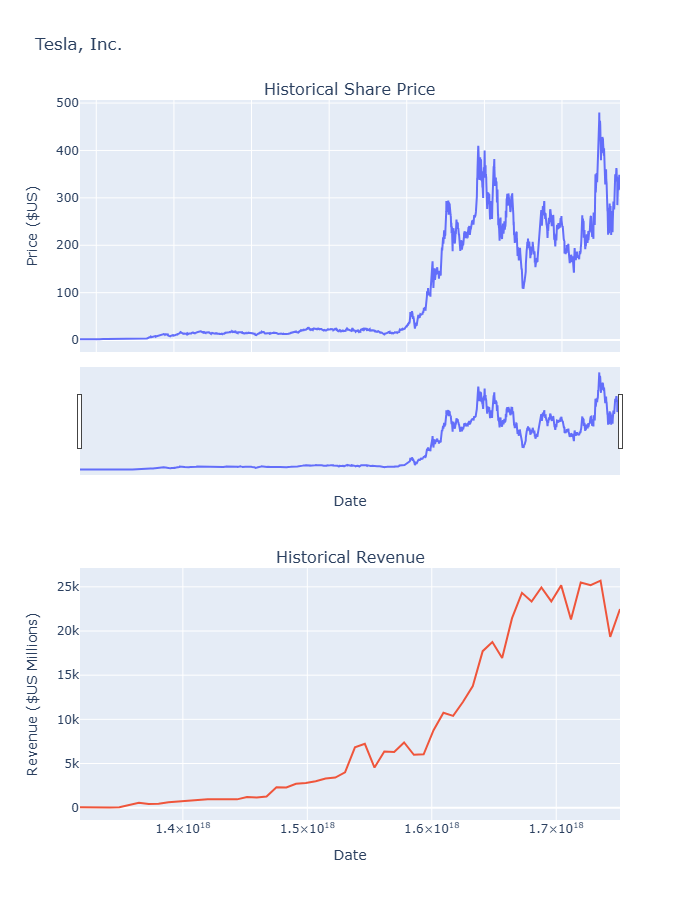

In [20]:
make_graph(tesla_data,tesla_revenue,tesla)

# Below is a function to render the image as png for displaying purposes. If png isn't necessary, the make_graph function above will be enough
def make_graph_png(stock_data,revenue_data,stock,png_path='./png_figures/plot.png'):
    original_renderer=pio.renderers.default
    pio.renderers.default = "png"
    fig=make_graph(stock_data,revenue_data,stock,show=False)
    fig.write_image(png_path)
    display(Image(filename=png_path))
    pio.renderers.default = original_renderer
make_graph_png(tesla_data,tesla_revenue,tesla)

## Plotting the GameStop Stock Graph


Finally, we will the `make_graph` function to graph the GameStop Stock Data.


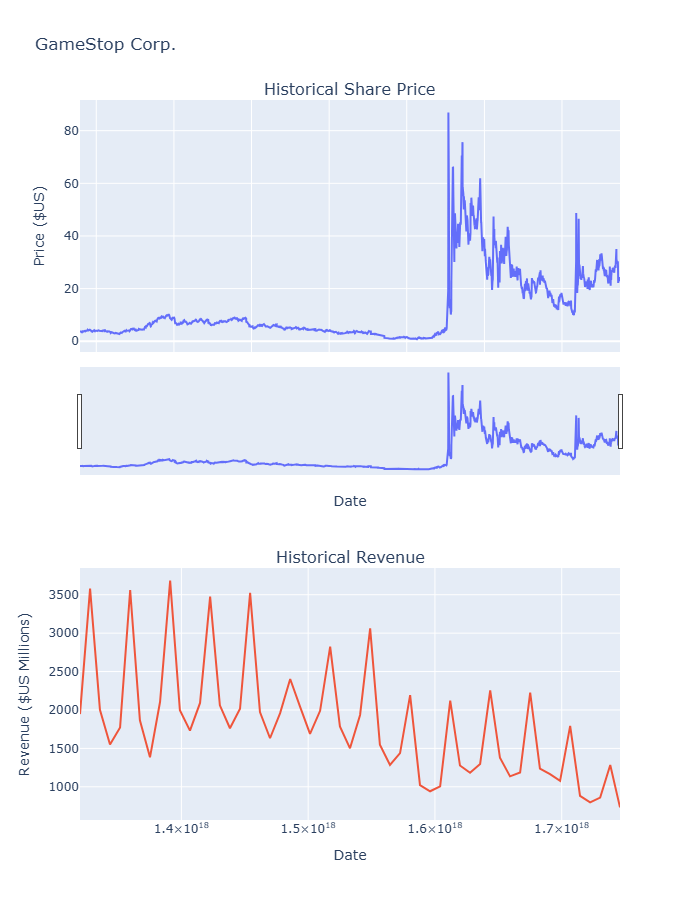

In [21]:
make_graph(gme_data,gme_revenue,gamestop)
#PNG (optional)
make_graph_png(gme_data,gme_revenue,gamestop)

## Saving the Extracted Data

Now that the data extraction and visualization was performed successfully, we can save the extracted data in .csv datasets.

In [22]:
tesla_data.to_csv("./Datasets/tesla_data.csv",index=False)
tesla_revenue.to_csv("./Datasets/tesla_revenue.csv",index=False)
gme_data.to_csv("./Datasets/gme_data.csv",index=False)
gme_revenue.to_csv("./Datasets/gme_revenue.csv",index=False)
print('Datasets Sucessfully Exported.')

Datasets Sucessfully Exported.


## Author
**Filipe B. Carvalho**

**Email:** [filipebraiman@gmail.com](mailto:filipebraiman@gmail.com)  
**LinkedIn:** [linkedin.com/in/filipe-b-carvalho](https://www.linkedin.com/in/filipe-b-carvalho)  
**GitHub:** [github.com/filipe-braiman](https://github.com/filipe-braiman)  

### About Me  
Data and AI professional with experience in **AI model evaluation, data annotation, and NLP projects**, currently contributing to AI initiatives at **Huawei**. Skilled in **Python, SQL, data visualization, machine learning, AI, and dataset building**, and certified through the **IBM Data Science Professional Certificate**. Multilingual in **Portuguese, English, Spanish, Turkish, and French**, bringing a linguistic and analytical perspective to data-driven problem solving. Passionate about leveraging data and AI to create practical, high-impact solutions.

---

### Version History

| Version | Date       | Changes                         |
|:--------:|:-----------|:--------------------------------|
| 1.0      | 2025-10-29 | First publication of the notebook |